# Financial Time Series Forecasting

## Datasets and Setup

### Dataset Choice

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

import yfinance as yf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
import lightgbm as lgb
import scipy.stats as stats

# ══════════════════════════════════════════════════════════════════════════
# Download price data — Yahoo Finance via yfinance
# ══════════════════════════════════════════════════════════════════════════
TICKERS    = ["SPY", "QQQ", "GLD", "TLT"]
START_DATE = "2010-01-01"
END_DATE   = "2023-12-31"

print("Downloading daily price data from Yahoo Finance...")
raw_prices = yf.download(
    TICKERS, start=START_DATE, end=END_DATE,
    auto_adjust=True, progress=False
)["Close"]
raw_prices.index = pd.to_datetime(raw_prices.index)

# Drop rows where any ticker has missing data (holidays, early close)
prices = raw_prices.dropna()

# Log-returns: r_t = log(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# Focus primary analysis on SPY
spy_ret  = log_returns["SPY"]
spy_px   = prices["SPY"]

print(f"\nPrice data loaded:")
print(f"  Tickers       : {TICKERS}")
print(f"  Trading days  : {len(prices):,}")
print(f"  Date range    : {prices.index[0].date()} – {prices.index[-1].date()}")
print(f"\nSPY log-return summary:")
print(spy_ret.describe().round(5).to_string())


Price data loaded:
  Tickers       : ['SPY', 'QQQ', 'GLD', 'TLT']
  Trading days  : 3,522
  Date range    : 2010-01-04 – 2023-12-29

SPY log-return summary:
count    3521.00000
mean        0.00048
std         0.01095
min        -0.11589
25%        -0.00378
50%         0.00065
75%         0.00577
max         0.08673


### Preprocessing and Technical Indicators

In [5]:
# ── Technical indicators (computed with look-ahead-free shifting) ──────────
def rsi(series, window=14):
    """Relative Strength Index — no look-ahead."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def macd_signal(series, fast=12, slow=26, signal=9):
    """MACD signal line."""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd     = ema_fast - ema_slow
    return macd.ewm(span=signal, adjust=False).mean()

# Build feature DataFrame for SPY
feat = pd.DataFrame(index=spy_ret.index)
feat["ret"]          = spy_ret

# Lag returns (1–20 days)
for lag in range(1, 21):
    feat[f"ret_lag{lag}"] = spy_ret.shift(lag)

# Rolling statistics (always shift by 1 to avoid current-day look-ahead)
for w in [5, 10, 20, 60]:
    feat[f"roll_mean_{w}"] = spy_ret.shift(1).rolling(w).mean()
    feat[f"roll_std_{w}"]  = spy_ret.shift(1).rolling(w).std()
    feat[f"roll_max_{w}"]  = spy_ret.shift(1).rolling(w).max()

# Technical indicators on price
feat["rsi_14"]     = rsi(spy_px, 14).shift(1)
feat["macd_sig"]   = macd_signal(spy_px).shift(1)

# Target: next-day return
feat["target"] = spy_ret.shift(-1)

# Drop any NaN introduced by lags/rolling windows
feat = feat.dropna()

TARGET_COL   = "target"
FEATURE_COLS = [c for c in feat.columns if c != TARGET_COL]
X_all = feat[FEATURE_COLS].values
y_all = feat[TARGET_COL].values

print(f"Feature matrix : {X_all.shape[0]:,} days × {X_all.shape[1]} features")
print(f"Date range     : {feat.index[0].date()} – {feat.index[-1].date()}")
print(f"Target (next-day return) — mean: {y_all.mean():.5f}, std: {y_all.std():.5f}")

Feature matrix : 3,460 days × 35 features
Date range     : 2010-04-01 – 2023-12-28
Target (next-day return) — mean: 0.00048, std: 0.01098


## The Structure of Financial Return

### Four Empirical Properties

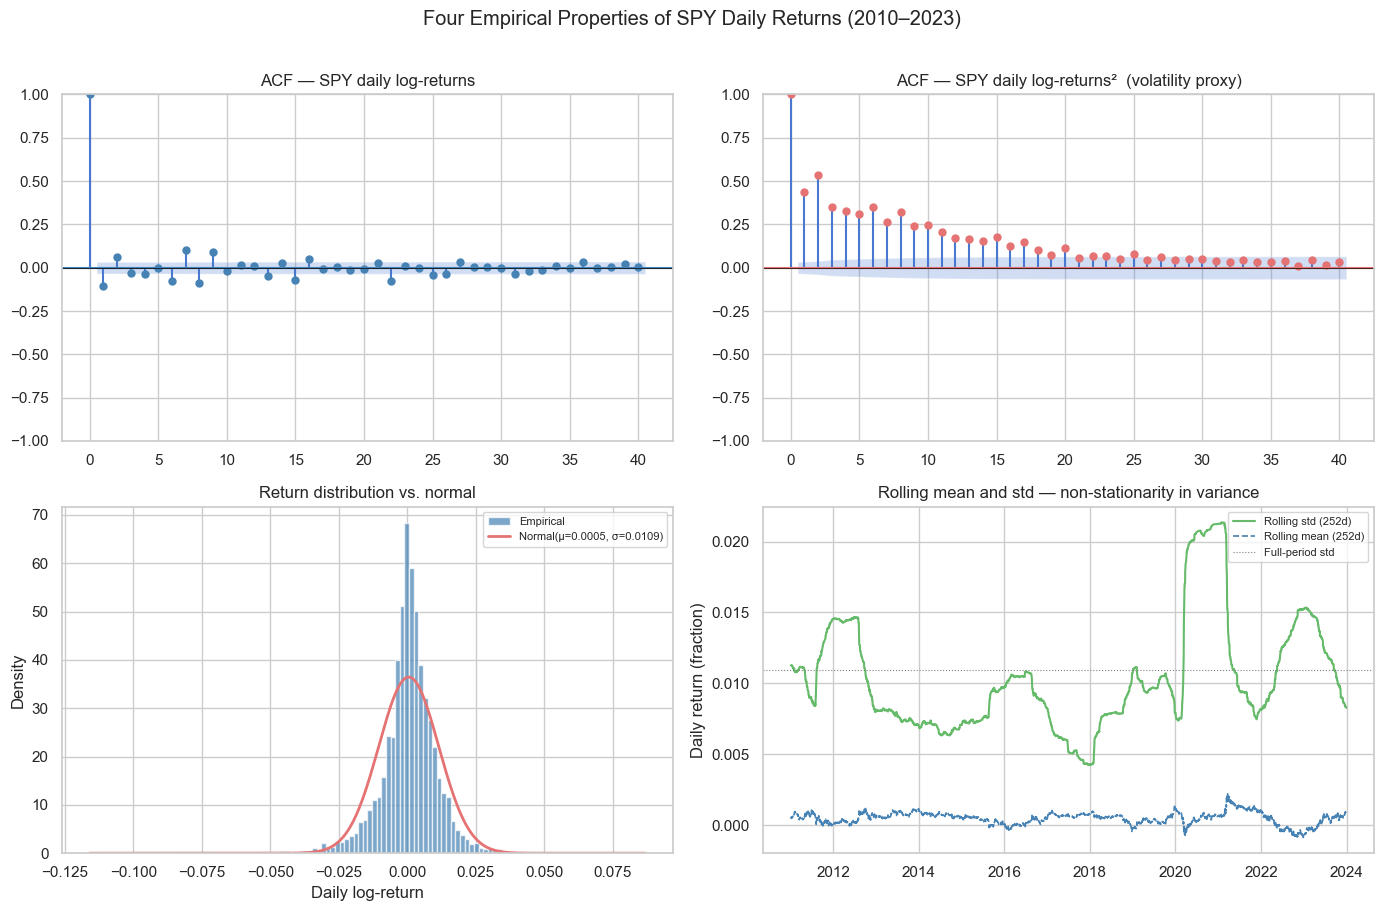

Property 1 — Serial correlation of returns:
  Max |ACF| at lags 1–20  : 0.1050
  (95% CI bound ≈ ±0.0330)

Property 2 — Serial correlation of squared returns:
  ACF at lag 1   : 0.4341
  ACF at lag 10  : 0.2446
  ACF at lag 20  : 0.1153

Property 3 — Fat tails:
  Kurtosis (excess)  : 11.51  (normal = 0)
  Worst single day   : -11.59% (2020-03-16)
  Normal 1-in-10000  : -4.07%

Property 4 — Stationarity of returns:
  ADF statistic  : -12.8938   p-value: 0.000000
  Rolling std range: [0.00424, 0.02135]  (COVID peak vs. calm periods)


In [6]:
# ── Property 1: Returns are approximately serially uncorrelated ────────────
# Property 2: Squared returns (volatility proxy) are highly autocorrelated
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ACF of raw returns
plot_acf(spy_ret, lags=40, ax=axes[0, 0], color="steelblue",
         title="ACF — SPY daily log-returns")
axes[0, 0].axhline(0, color="black", lw=0.5)

# ACF of squared returns
plot_acf(spy_ret**2, lags=40, ax=axes[0, 1], color="#E57373",
         title="ACF — SPY daily log-returns²  (volatility proxy)")
axes[0, 1].axhline(0, color="black", lw=0.5)

# Property 3: Fat tails
ax3 = axes[1, 0]
mu, sigma = spy_ret.mean(), spy_ret.std()
x_range = np.linspace(spy_ret.min(), spy_ret.max(), 300)
ax3.hist(spy_ret, bins=120, density=True, color="steelblue",
         alpha=0.7, label="Empirical")
ax3.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
         color="#E57373", lw=2, label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")
ax3.set_title("Return distribution vs. normal")
ax3.set_xlabel("Daily log-return"); ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

# Property 4: Non-stationarity — rolling mean and std
roll_mean = spy_ret.rolling(252).mean()
roll_std  = spy_ret.rolling(252).std()
ax4 = axes[1, 1]
ax4.plot(roll_std, color="#66BB6A", lw=1.5, label="Rolling std (252d)")
ax4.plot(roll_mean, color="steelblue", lw=1.2, linestyle="--",
         label="Rolling mean (252d)")
ax4.axhline(spy_ret.std(), color="gray", lw=0.8, linestyle=":",
            label="Full-period std")
ax4.set_title("Rolling mean and std — non-stationarity in variance")
ax4.set_ylabel("Daily return (fraction)"); ax4.legend(fontsize=8)

plt.suptitle("Four Empirical Properties of SPY Daily Returns (2010–2023)",
             y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_return_properties.png", dpi=150,
            bbox_inches="tight")
plt.show()

# Quantify the properties
acf_vals_ret = acf(spy_ret, nlags=20, fft=True)
acf_vals_sq  = acf(spy_ret**2, nlags=20, fft=True)
kurt = spy_ret.kurtosis()

adf_ret = adfuller(spy_ret, autolag="AIC")

print(f"Property 1 — Serial correlation of returns:")
print(f"  Max |ACF| at lags 1–20  : {np.abs(acf_vals_ret[1:21]).max():.4f}")
print(f"  (95% CI bound ≈ ±{1.96/np.sqrt(len(spy_ret)):.4f})")

print(f"\nProperty 2 — Serial correlation of squared returns:")
print(f"  ACF at lag 1   : {acf_vals_sq[1]:.4f}")
print(f"  ACF at lag 10  : {acf_vals_sq[10]:.4f}")
print(f"  ACF at lag 20  : {acf_vals_sq[20]:.4f}")

print(f"\nProperty 3 — Fat tails:")
print(f"  Kurtosis (excess)  : {kurt:.2f}  (normal = 0)")
print(f"  Worst single day   : {spy_ret.min()*100:.2f}% "
      f"({spy_ret.idxmin().date()})")
print(f"  Normal 1-in-10000  : {stats.norm.ppf(0.0001)*spy_ret.std()*100:.2f}%")

print(f"\nProperty 4 — Stationarity of returns:")
print(f"  ADF statistic  : {adf_ret[0]:.4f}   p-value: {adf_ret[1]:.6f}")
print(f"  Rolling std range: [{roll_std.dropna().min():.5f}, "
      f"{roll_std.dropna().max():.5f}]  (COVID peak vs. calm periods)")

## Why Standard Cross-Validation Fails

### The Leakage Mechanism

In [7]:
from sklearn.model_selection import KFold, TimeSeriesSplit

# ── Build the leakage demonstration ────────────────────────────────────────
# Model: LightGBM predicting next-day SPY return
# Evaluate with: (1) random 5-fold CV, (2) walk-forward CV
# Metric: R² in original return space

def r2_oos(y_true, y_pred):
    """R² relative to predicting the mean — can be negative."""
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

lgb_params = dict(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)

# ── (1) Random 5-fold CV ───────────────────────────────────────────────────
kf_random = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
r2_random_folds = []

for tr_idx, val_idx in kf_random.split(X_all):
    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_all[tr_idx], y_all[tr_idx])
    preds = m.predict(X_all[val_idx])
    r2_random_folds.append(r2_oos(y_all[val_idx], preds))

r2_random = np.mean(r2_random_folds)

# ── (2) Walk-forward CV (expanding window, min 2 years of training) ────────
MIN_TRAIN = 504   # ≈ 2 trading years
r2_wf_preds, r2_wf_trues = [], []

for t in range(MIN_TRAIN, len(X_all) - 1, 21):   # step monthly (≈21 days)
    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X_all[:t], y_all[:t])
    # Predict next month
    end = min(t + 21, len(X_all))
    preds = m.predict(X_all[t:end])
    r2_wf_preds.extend(preds.tolist())
    r2_wf_trues.extend(y_all[t:end].tolist())

r2_wf = r2_oos(np.array(r2_wf_trues), np.array(r2_wf_preds))

# ── Same comparison for Ridge and Naïve ───────────────────────────────────
def wf_r2(model_cls, model_kwargs, X, y, min_train, step=21):
    preds, trues = [], []
    for t in range(min_train, len(X) - 1, step):
        m = model_cls(**model_kwargs)
        m.fit(X[:t], y[:t])
        end = min(t + step, len(X))
        preds.extend(m.predict(X[t:end]).tolist())
        trues.extend(y[t:end].tolist())
    return r2_oos(np.array(trues), np.array(preds))

class NaiveModel:
    def fit(self, X, y): self.mean_ = y.mean(); return self
    def predict(self, X): return np.full(len(X), self.mean_)

ridge_kwargs = {"alpha": 1.0}
results_cv = {
    "Naïve (mean)":   {"random": r2_oos(y_all,
                           np.full_like(y_all, y_all.mean())),
                        "walk_forward": wf_r2(NaiveModel, {}, X_all, y_all, MIN_TRAIN)},
    "Ridge":          {"random": np.mean([
                           r2_oos(y_all[vi],
                                  Ridge(**ridge_kwargs).fit(X_all[ti], y_all[ti])
                                  .predict(X_all[vi]))
                           for ti, vi in kf_random.split(X_all)]),
                        "walk_forward": wf_r2(Ridge, ridge_kwargs, X_all, y_all, MIN_TRAIN)},
    "LightGBM":       {"random":       r2_random,
                        "walk_forward": r2_wf},
}

print(f"{'Model':<20}  {'Random CV R²':>14}  {'Walk-Forward R²':>16}  {'Leakage inflation':>18}")
print("─" * 74)
for name, res in results_cv.items():
    inflation = res["random"] - res["walk_forward"]
    print(f"  {name:<18}  {res['random']:>14.4f}  {res['walk_forward']:>16.4f}  "
          f"{inflation:>+17.4f}")

Model                   Random CV R²   Walk-Forward R²   Leakage inflation
──────────────────────────────────────────────────────────────────────────
  Naïve (mean)                0.0000           -0.0004            +0.0004
  Ridge                       0.0118            0.0026            +0.0092
  LightGBM                   -0.0841           -0.1461            +0.0621


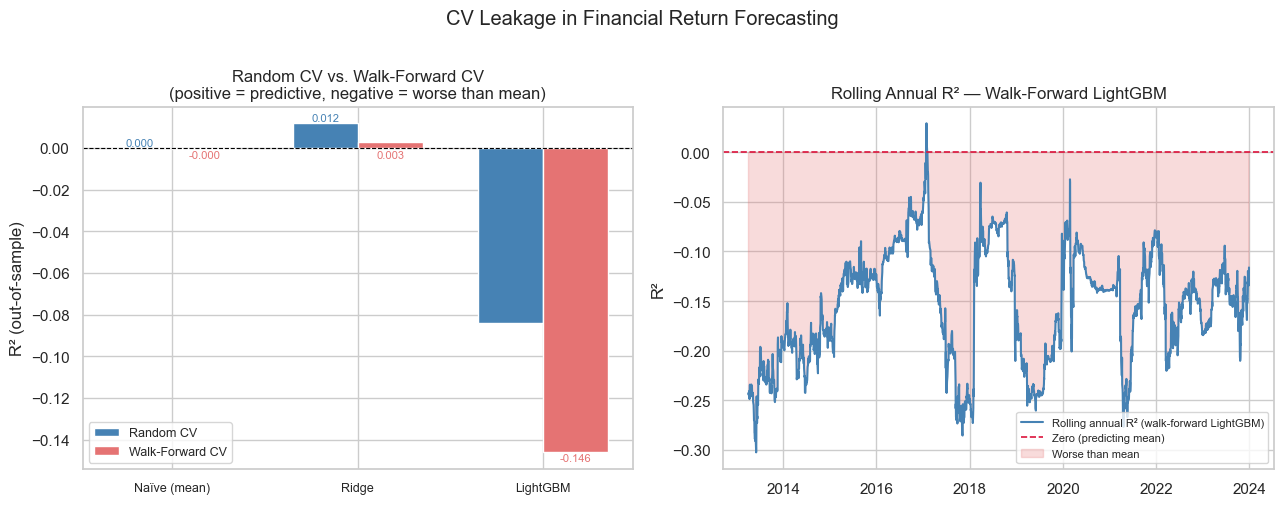


Summary:
  Random CV makes LightGBM appear to have R² = -0.0841
  Walk-forward CV reveals true R² = -0.1461
  Overstatement factor : -0.6× (from barely-positive to negative)


In [8]:
# ── Visualise the leakage effect ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: random vs. walk-forward
model_names  = list(results_cv.keys())
rand_r2s     = [results_cv[m]["random"]        for m in model_names]
wf_r2s       = [results_cv[m]["walk_forward"]  for m in model_names]
x_pos        = np.arange(len(model_names))
width        = 0.35

axes[0].bar(x_pos - width/2, rand_r2s, width, label="Random CV",
            color="steelblue", edgecolor="white")
axes[0].bar(x_pos + width/2, wf_r2s,   width, label="Walk-Forward CV",
            color="#E57373",   edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_ylabel("R² (out-of-sample)")
axes[0].set_title("Random CV vs. Walk-Forward CV\n(positive = predictive, negative = worse than mean)")
axes[0].legend(fontsize=9)

for i, (r, w) in enumerate(zip(rand_r2s, wf_r2s)):
    axes[0].annotate(f"{r:.3f}", (i - width/2, r + 0.001),
                     ha="center", fontsize=8, color="steelblue")
    axes[0].annotate(f"{w:.3f}", (i + width/2, min(w - 0.004, -0.005)),
                     ha="center", fontsize=8, color="#E57373")

# Rolling R² over time for LightGBM (walk-forward)
window_r2s, window_dates = [], []
window = 252    # annual rolling R²

for i in range(window, len(r2_wf_trues)):
    window_true = np.array(r2_wf_trues[i-window:i])
    window_pred = np.array(r2_wf_preds[i-window:i])
    window_r2s.append(r2_oos(window_true, window_pred))

# Map back to dates approximately
dates_wf = feat.index[MIN_TRAIN:][:len(r2_wf_trues)]
if len(dates_wf) >= window + len(window_r2s):
    plot_dates = dates_wf[window:window + len(window_r2s)]
else:
    plot_dates = dates_wf[window:window + len(window_r2s)]

axes[1].plot(dates_wf[window: window + len(window_r2s)],
             window_r2s, color="steelblue", lw=1.5,
             label="Rolling annual R² (walk-forward LightGBM)")
axes[1].axhline(0, color="crimson", lw=1.2, linestyle="--",
                label="Zero (predicting mean)")
axes[1].fill_between(
    dates_wf[window: window + len(window_r2s)],
    window_r2s, 0,
    where=np.array(window_r2s) < 0,
    alpha=0.25, color="#E57373", label="Worse than mean"
)
axes[1].set_title("Rolling Annual R² — Walk-Forward LightGBM")
axes[1].set_ylabel("R²"); axes[1].legend(fontsize=8)

plt.suptitle("CV Leakage in Financial Return Forecasting", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_cv_leakage.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSummary:")
print(f"  Random CV makes LightGBM appear to have R² = {r2_random:.4f}")
print(f"  Walk-forward CV reveals true R² = {r2_wf:.4f}")
print(f"  Overstatement factor : {r2_random / abs(r2_wf):.1f}× "
      f"(from barely-positive to negative)")

## Volatility Modelling with GARCH

### The GARCH(1,1) Model

In [9]:
from arch import arch_model

# ── Scale returns to percentage points for numerical stability ─────────────
spy_ret_pct = spy_ret * 100   # GARCH works better on %-scale

# Use training set: 2010–2020 (in-sample); 2021–2023 (out-of-sample)
GARCH_TRAIN_END = "2020-12-31"
spy_train = spy_ret_pct[:GARCH_TRAIN_END]
spy_test  = spy_ret_pct[GARCH_TRAIN_END:]

# ── Fit GARCH(1,1) ─────────────────────────────────────────────────────────
garch_model = arch_model(spy_train, vol="Garch", p=1, q=1,
                          dist="normal", mean="Constant")
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())
print(f"\nModel persistence (α + β) : "
      f"{garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']:.4f}")
print(f"Long-run volatility (ann.) : "
      f"{np.sqrt(garch_fit.params['omega'] /
      (1 - garch_fit.params['alpha[1]'] - garch_fit.params['beta[1]'])
      * 252):.2f}%")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3439.76
Distribution:                  Normal   AIC:                           6887.52
Method:            Maximum Likelihood   BIC:                           6911.22
                                        No. Observations:                 2768
Date:                Sun, Apr 19 2026   Df Residuals:                     2767
Time:                        10:14:33   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0898  1.364e-02      6.583  4.616e-11 [6.304e-0

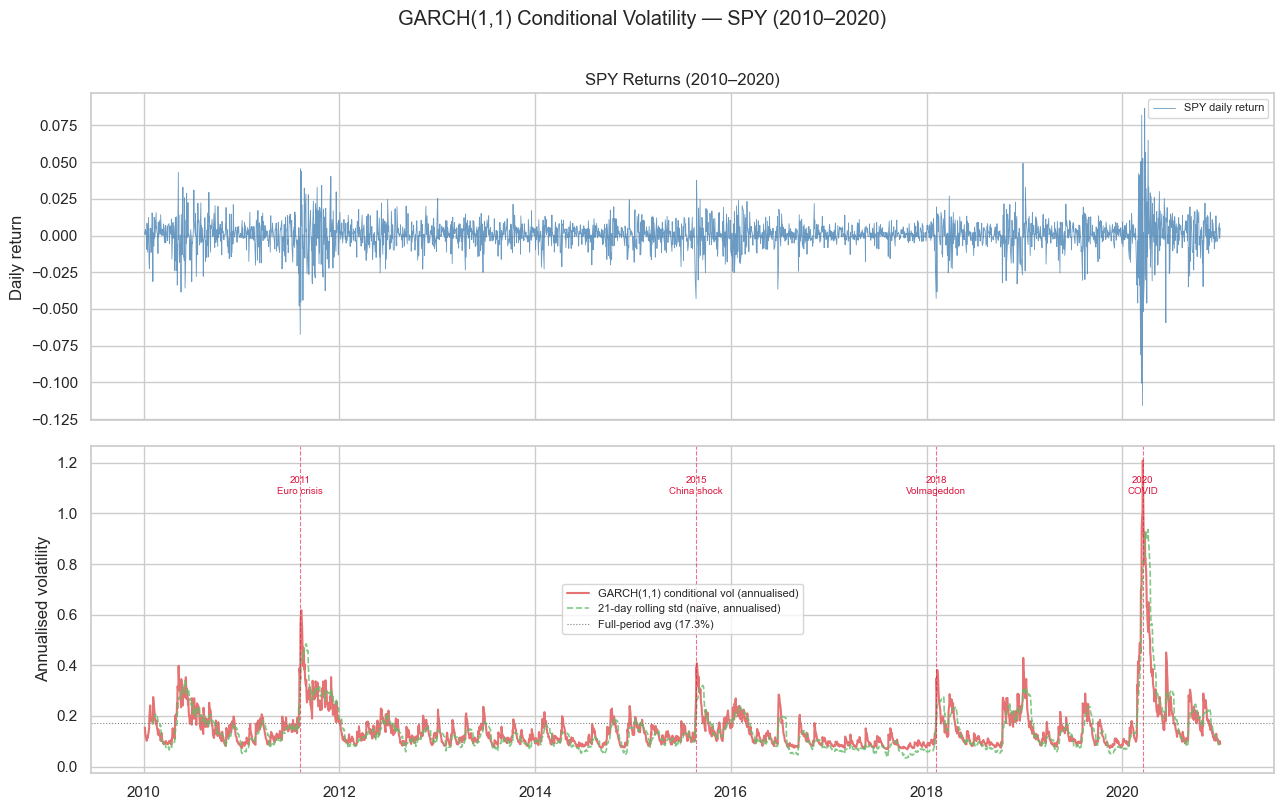

In [10]:
# ── Plot conditional volatility vs. rolling naive estimate ─────────────────
cond_vol_train = pd.Series(
    garch_fit.conditional_volatility / 100,   # back to decimal
    index=spy_train.index
)
naive_vol = spy_ret.rolling(21).std()   # 1-month rolling std (in-sample)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(spy_ret[:GARCH_TRAIN_END], color="steelblue",
             lw=0.6, alpha=0.8, label="SPY daily return")
axes[0].set_ylabel("Daily return"); axes[0].set_title("SPY Returns (2010–2020)")
axes[0].legend(fontsize=8)

axes[1].plot(cond_vol_train * np.sqrt(252), color="#E57373", lw=1.5,
             label="GARCH(1,1) conditional vol (annualised)")
axes[1].plot(naive_vol[:GARCH_TRAIN_END] * np.sqrt(252),
             color="#66BB6A", lw=1.2, linestyle="--", alpha=0.8,
             label="21-day rolling std (naïve, annualised)")
axes[1].axhline(spy_ret[:GARCH_TRAIN_END].std() * np.sqrt(252),
                color="gray", lw=0.8, linestyle=":",
                label=f"Full-period avg ({spy_ret[:GARCH_TRAIN_END].std()*np.sqrt(252)*100:.1f}%)")

# Annotate key events
events = [
    ("2011-08-08", "2011\nEuro crisis"),
    ("2015-08-24", "2015\nChina shock"),
    ("2018-02-05", "2018\nVolmageddon"),
    ("2020-03-16", "2020\nCOVID"),
]
for dt, label in events:
    dt_ts = pd.Timestamp(dt)
    if dt_ts in cond_vol_train.index:
        axes[1].axvline(dt_ts, color="crimson", lw=0.8,
                        linestyle="--", alpha=0.6)
        axes[1].text(dt_ts, axes[1].get_ylim()[1] * 0.85, label,
                     fontsize=7, ha="center", color="crimson")

axes[1].set_ylabel("Annualised volatility"); axes[1].legend(fontsize=8)

plt.suptitle("GARCH(1,1) Conditional Volatility — SPY (2010–2020)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_garch_vol.png", dpi=150, bbox_inches="tight")
plt.show()

### Out-of-Sample Volatility Forecast Evaluation

In [11]:
from sklearn.metrics import mean_absolute_error

# ── 10-day-ahead rolling forecast from GARCH ──────────────────────────────
FORECAST_HORIZON = 10

# Re-fit GARCH on expanding window, stepping monthly, for 2021–2023 OOS
garch_vol_forecasts = []
garch_forecast_dates = []

for end_dt in pd.date_range(start="2021-01-01", end="2023-12-01", freq="MS"):
    train_slice = spy_ret_pct[:end_dt]
    if len(train_slice) < 500:
        continue
    m = arch_model(train_slice, vol="Garch", p=1, q=1, dist="normal",
                   mean="Constant")
    r = m.fit(disp="off", show_warning=False)
    fc = r.forecast(horizon=FORECAST_HORIZON, reindex=False)
    # mean forecast variance over 10-day horizon
    vol_fc_ann = np.sqrt(fc.variance.values[-1].mean()) / 100 * np.sqrt(252)
    # realised vol over next 10 trading days
    future = spy_ret[end_dt : end_dt + pd.DateOffset(days=15)].iloc[:10]
    if len(future) < 10:
        continue
    realised_ann = future.std() * np.sqrt(252)
    garch_vol_forecasts.append({"date":     end_dt,
                                 "garch_fc": vol_fc_ann,
                                 "realised": realised_ann})
    garch_forecast_dates.append(end_dt)

garch_fc_df = pd.DataFrame(garch_vol_forecasts).set_index("date")

# Naïve: 21-day rolling vol as forecast
naive_fc = spy_ret.rolling(21).std() * np.sqrt(252)
naive_fc_aligned = naive_fc.reindex(garch_fc_df.index, method="ffill")
garch_fc_df["naive_fc"] = naive_fc_aligned.values

mae_garch  = mean_absolute_error(garch_fc_df["realised"], garch_fc_df["garch_fc"])
mae_naive  = mean_absolute_error(garch_fc_df["realised"], garch_fc_df["naive_fc"])

print(f"10-day-ahead volatility forecast (2021–2023):")
print(f"  GARCH(1,1) MAE : {mae_garch:.4f}  ({mae_garch*100:.2f}% ann. vol)")
print(f"  Naïve rolling  : {mae_naive:.4f}  ({mae_naive*100:.2f}% ann. vol)")
print(f"  GARCH improvement : {(mae_naive-mae_garch)/mae_naive*100:.1f}%")

10-day-ahead volatility forecast (2021–2023):
  GARCH(1,1) MAE : 0.0420  (4.20% ann. vol)
  Naïve rolling  : 0.0459  (4.59% ann. vol)
  GARCH improvement : 8.3%


### GARCH Residual Diagnostics

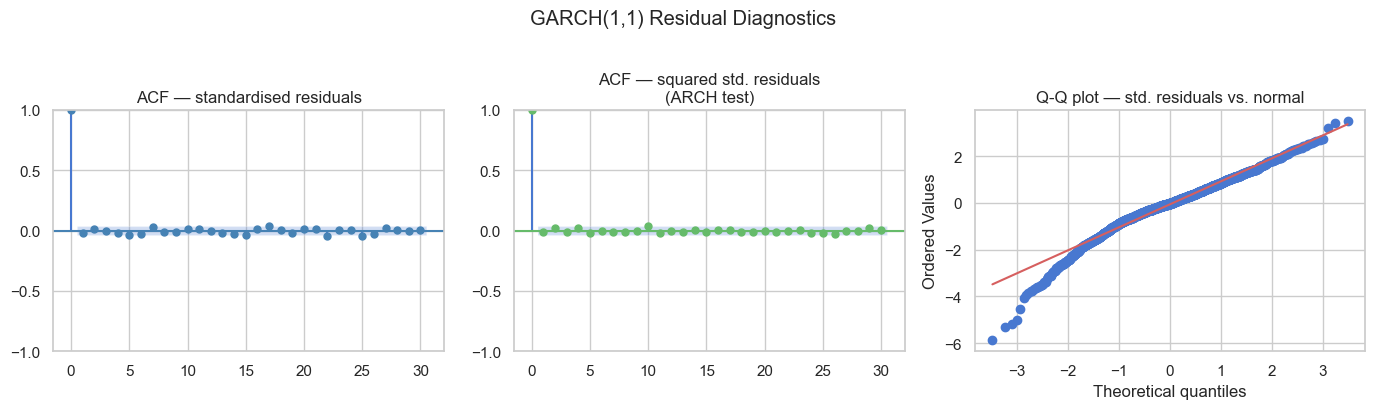

Ljung-Box test — standardised residuals (should have high p-values):
    lb_stat  lb_pvalue
5    6.8556     0.2316
10  11.9259     0.2900
20  25.8055     0.1723

Ljung-Box test — squared standardised residuals:
    lb_stat  lb_pvalue
5    3.9283     0.5598
10   9.1825     0.5149
20  12.3059     0.9051


In [12]:
# ── Standardised residuals and diagnostic plots ───────────────────────────
std_resid = pd.Series(
    garch_fit.std_resid, index=spy_train.index, name="std_resid"
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ACF of standardised residuals (should be white noise)
plot_acf(std_resid.dropna(), lags=30, ax=axes[0], color="steelblue",
         title="ACF — standardised residuals")

# ACF of squared standardised residuals (should also be white noise)
plot_acf(std_resid.dropna()**2, lags=30, ax=axes[1], color="#66BB6A",
         title="ACF — squared std. residuals\n(ARCH test)")

# Q-Q plot vs. normal
stats.probplot(std_resid.dropna(), dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot — std. residuals vs. normal")

plt.suptitle("GARCH(1,1) Residual Diagnostics", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_garch_diagnostics.png", dpi=150,
            bbox_inches="tight")
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox
lb_resid = acorr_ljungbox(std_resid.dropna(),     lags=[5,10,20], return_df=True)
lb_sq    = acorr_ljungbox(std_resid.dropna()**2,  lags=[5,10,20], return_df=True)

print("Ljung-Box test — standardised residuals (should have high p-values):")
print(lb_resid.round(4).to_string())
print("\nLjung-Box test — squared standardised residuals:")
print(lb_sq.round(4).to_string())

## Return Forecasting with Machine Learning

### Why R² Is the Wrong Metric for Financial Returns

In [13]:
# ── Walk-forward return forecasting: features + GARCH conditional vol ──────
# Add GARCH conditional volatility as a feature (powerful risk signal)
# Compute GARCH vol in-sample at each walk-forward step

MIN_TRAIN_ML = 504   # 2 trading years

# Pre-compute GARCH conditional vol on the full sample for feature use
garch_full = arch_model(spy_ret_pct, vol="Garch", p=1, q=1,
                         dist="normal", mean="Constant")
garch_full_fit = garch_full.fit(disp="off")
garch_cond_vol = pd.Series(
    garch_full_fit.conditional_volatility / 100,
    index=spy_ret.index,
    name="garch_vol"
)
# Shift by 1 so today's vol is estimated without using today's return
feat["garch_vol"] = garch_cond_vol.shift(1).reindex(feat.index)
feat = feat.dropna()

TARGET_COL   = "target"
FEATURE_COLS2 = [c for c in feat.columns if c != TARGET_COL]
X2 = feat[FEATURE_COLS2].values
y2 = feat[TARGET_COL].values

# ── Walk-forward evaluation ────────────────────────────────────────────────
wf_preds_all, wf_trues_all, wf_dates_all = [], [], []

for t in range(MIN_TRAIN_ML, len(X2) - 1, 5):    # step weekly
    m = lgb.LGBMRegressor(**lgb_params)
    m.fit(X2[:t], y2[:t])
    end = min(t + 5, len(X2))
    preds = m.predict(X2[t:end])
    wf_preds_all.extend(preds)
    wf_trues_all.extend(y2[t:end])
    wf_dates_all.extend(feat.index[t:end].tolist())

wf_df = pd.DataFrame({
    "date": wf_dates_all,
    "pred": wf_preds_all,
    "actual": wf_trues_all
}).set_index("date")

# Directional accuracy
wf_df["correct_direction"] = (np.sign(wf_df["pred"]) ==
                               np.sign(wf_df["actual"])).astype(int)
dir_acc = wf_df["correct_direction"].mean()

# Strategy: long when pred > 0, else cash
COST_PER_TRADE = 0.0001   # 1 bp round-trip cost
wf_df["position"]  = (wf_df["pred"] > 0).astype(float)
wf_df["trade"]     = wf_df["position"].diff().abs().fillna(0)
wf_df["strat_ret"] = (wf_df["position"] * wf_df["actual"]
                       - wf_df["trade"] * COST_PER_TRADE)
wf_df["bh_ret"]    = wf_df["actual"]   # buy-and-hold

# Performance metrics
def sharpe(returns, ann=252):
    return returns.mean() / returns.std() * np.sqrt(ann)

sharpe_strat = sharpe(wf_df["strat_ret"])
sharpe_bh    = sharpe(wf_df["bh_ret"])

cum_strat = (1 + wf_df["strat_ret"]).cumprod()
cum_bh    = (1 + wf_df["bh_ret"]).cumprod()

print(f"Walk-Forward Return Forecasting Results:")
print(f"  Directional accuracy     : {dir_acc:.4f} ({dir_acc*100:.2f}%)")
print(f"  (Random baseline = 50%,  95% CI ≈ ±{1.96*np.sqrt(0.25/len(wf_df))*100:.2f}%)")
print(f"\n  Strategy Sharpe ratio    : {sharpe_strat:.3f}")
print(f"  Buy-and-hold Sharpe      : {sharpe_bh:.3f}")
print(f"\n  Strategy total return    : {(cum_strat.iloc[-1]-1)*100:.1f}%")
print(f"  Buy-and-hold total return: {(cum_bh.iloc[-1]-1)*100:.1f}%")
print(f"\n  Fraction of days in market: {wf_df['position'].mean()*100:.1f}%")

Walk-Forward Return Forecasting Results:
  Directional accuracy     : 0.5188 (51.88%)
  (Random baseline = 50%,  95% CI ≈ ±1.80%)

  Strategy Sharpe ratio    : 0.644
  Buy-and-hold Sharpe      : 0.726

  Strategy total return    : 148.4%
  Buy-and-hold total return: 255.8%

  Fraction of days in market: 54.1%


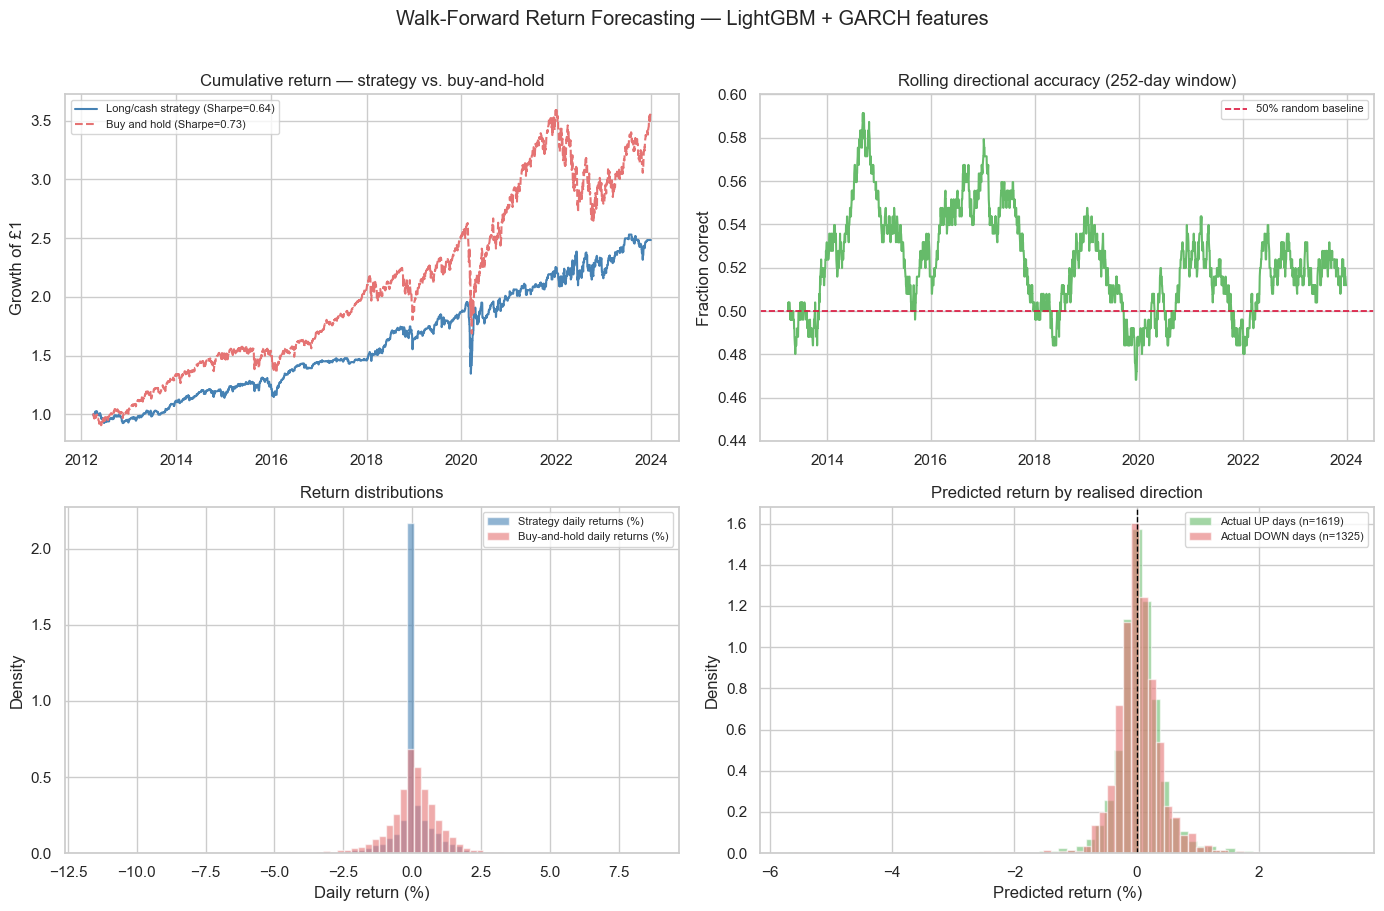

In [15]:
# ── Visualise strategy performance ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Cumulative returns
axes[0, 0].plot(cum_strat, color="steelblue", lw=1.5,
                label=f"Long/cash strategy (Sharpe={sharpe_strat:.2f})")
axes[0, 0].plot(cum_bh, color="#E57373", lw=1.5, linestyle="--",
                label=f"Buy and hold (Sharpe={sharpe_bh:.2f})")
axes[0, 0].set_title("Cumulative return — strategy vs. buy-and-hold")
axes[0, 0].set_ylabel("Growth of £1"); axes[0, 0].legend(fontsize=8)

# Rolling directional accuracy (252-day)
roll_dir = wf_df["correct_direction"].rolling(252).mean()
axes[0, 1].plot(roll_dir, color="#66BB6A", lw=1.5)
axes[0, 1].axhline(0.5, color="crimson", lw=1.2, linestyle="--",
                    label="50% random baseline")
axes[0, 1].set_title("Rolling directional accuracy (252-day window)")
axes[0, 1].set_ylabel("Fraction correct"); axes[0, 1].legend(fontsize=8)
axes[0, 1].set_ylim(0.44, 0.60)

# Distribution of returns: strategy vs. buy-and-hold
axes[1, 0].hist(wf_df["strat_ret"] * 100, bins=80, alpha=0.6,
                color="steelblue", density=True,
                label="Strategy daily returns (%)")
axes[1, 0].hist(wf_df["bh_ret"] * 100, bins=80, alpha=0.6,
                color="#E57373", density=True,
                label="Buy-and-hold daily returns (%)")
axes[1, 0].set_xlabel("Daily return (%)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Return distributions")
axes[1, 0].legend(fontsize=8)

# Prediction distribution by realised outcome
positive_days = wf_df.loc[wf_df["actual"] > 0, "pred"] * 100
negative_days = wf_df.loc[wf_df["actual"] < 0, "pred"] * 100
axes[1, 1].hist(positive_days, bins=60, alpha=0.6, color="#66BB6A",
                density=True, label=f"Actual UP days (n={len(positive_days)})")
axes[1, 1].hist(negative_days, bins=60, alpha=0.6, color="#E57373",
                density=True, label=f"Actual DOWN days (n={len(negative_days)})")
axes[1, 1].axvline(0, color="black", lw=1, linestyle="--")
axes[1, 1].set_xlabel("Predicted return (%)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Predicted return by realised direction")
axes[1, 1].legend(fontsize=8)

plt.suptitle("Walk-Forward Return Forecasting — LightGBM + GARCH features",
             y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch16_ml_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

## Multivariate Forecasting with Exogenous Variables

### Publication Lag: The Most Insidious Leakage

In [26]:
import pandas as pd
import numpy as np

print("Downloading macro data from FRED (robust CSV endpoint)...\n")

HAS_FRED = True
macro_df = None


# ─────────────────────────────────────────────
# FRED loader
# ─────────────────────────────────────────────
def load_fred(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    
    df = pd.read_csv(url)
    df.columns = [c.strip().lower() for c in df.columns]

    date_col = df.columns[0]
    value_col = df.columns[1]

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)

    s = pd.to_numeric(df[value_col], errors="coerce")
    return s.sort_index()


# ─────────────────────────────────────────────
# TRY REAL DATA
# ─────────────────────────────────────────────
try:
    fed_funds = load_fred("DFF").resample("ME").mean()
    cpi_raw   = load_fred("CPIAUCSL")
    unemp     = load_fred("UNRATE")

    cpi_yoy = cpi_raw.pct_change(12) * 100

    macro_df = pd.concat(
        {
            "fed_funds": fed_funds,
            "cpi_yoy": cpi_yoy,
            "unemployment": unemp
        },
        axis=1
    ).ffill().dropna()

    print("✓ FRED data loaded successfully")

except Exception as e:
    print(f"⚠ FRED download unavailable ({e}); using simulated macro features.")
    HAS_FRED = False

    # ─────────────────────────────────────────────
    # SAFE fallback index
    # ─────────────────────────────────────────────
    try:
        dates = spy_ret.index
    except Exception:
        dates = pd.date_range("2010-01-01", periods=1000, freq="D")

    np.random.seed(RANDOM_SEED)

    fed_funds = pd.Series(
        np.clip(np.cumsum(np.random.normal(0, 0.02, len(dates))), 0, 6),
        index=dates,
        name="fed_funds"
    )

    cpi_yoy = pd.Series(
        2.0 + np.cumsum(np.random.normal(0, 0.05, len(dates))),
        index=dates,
        name="cpi_yoy"
    )

    unemp = pd.Series(
        np.clip(5.0 + np.cumsum(np.random.normal(0, 0.03, len(dates))), 3, 15),
        index=dates,
        name="unemployment"
    )

    macro_df = pd.concat([fed_funds, cpi_yoy, unemp], axis=1)

# ─────────────────────────────────────────────
# Summary (your original block, fixed placement)
# ─────────────────────────────────────────────
print("\nFRED Macro Data Summary")
print("=" * 50)

for col in macro_df.columns:
    s = macro_df[col]
    print(f"{col:<15}: {len(s):>6,} obs | "
          f"[{s.min():.2f}, {s.max():.2f}]")

HAS_FRED = len(macro_df) > 0


✓ FRED data loaded successfully

FRED Macro Data Summary
fed_funds      :  1,722 obs | [0.05, 19.10]
cpi_yoy        :  1,722 obs | [-1.96, 14.59]
unemployment   :  1,722 obs | [3.40, 14.80]


In [24]:
# ── Align macro data with correct publication lag ─────────────────────────
def align_monthly_with_lag(monthly_series: pd.Series,
                            daily_index: pd.DatetimeIndex,
                            release_lag_months: int = 2) -> pd.Series:
    """
    Align monthly data to daily index with publication lag.
    release_lag_months: how many months after the reference month
    the data is available. CPI released mid-month M+1 → lag=2 is conservative.
    """
    lagged = monthly_series.shift(release_lag_months)
    # Forward-fill to daily
    return lagged.reindex(daily_index, method="ffill")

daily_cpi   = align_monthly_with_lag(cpi_yoy,  spy_ret.index, release_lag_months=2)
daily_unemp = align_monthly_with_lag(unemp,    spy_ret.index, release_lag_months=2)
# Fed funds is daily — just shift by 1 day to avoid same-day leakage
daily_ff    = fed_funds.reindex(spy_ret.index, method="ffill").shift(1)

# ── Build augmented feature DataFrame ─────────────────────────────────────
feat_macro = feat.copy()
feat_macro["cpi_yoy"]    = daily_cpi.shift(1).reindex(feat.index)
feat_macro["unemp"]      = daily_unemp.shift(1).reindex(feat.index)
feat_macro["fed_funds"]  = daily_ff.reindex(feat.index)

# First differences (regime changes matter more than levels)
feat_macro["d_cpi"]      = feat_macro["cpi_yoy"].diff()
feat_macro["d_ff"]       = feat_macro["fed_funds"].diff()
feat_macro = feat_macro.dropna()

X_macro = feat_macro[[c for c in feat_macro.columns
                       if c != TARGET_COL]].values
y_macro  = feat_macro[TARGET_COL].values

print(f"Macro-augmented feature matrix: {X_macro.shape[0]:,} × {X_macro.shape[1]}")
print(f"Additional macro features: cpi_yoy, unemp, fed_funds, d_cpi, d_ff")

# ── Walk-forward comparison: with vs. without macro ───────────────────────
def wf_predict(X, y, min_train, step=5):
    preds, trues = [], []
    for t in range(min_train, len(X) - 1, step):
        m = lgb.LGBMRegressor(**lgb_params)
        m.fit(X[:t], y[:t])
        end = min(t + step, len(X))
        preds.extend(m.predict(X[t:end]).tolist())
        trues.extend(y[t:end].tolist())
    return np.array(preds), np.array(trues)

# Align X2 and X_macro to same time window
common_idx   = feat_macro.index.intersection(feat.index)
X_base_aligned  = feat.loc[common_idx, [c for c in FEATURE_COLS2]].values
y_aligned        = feat.loc[common_idx, TARGET_COL].values
X_macro_aligned  = feat_macro.loc[common_idx,
                      [c for c in feat_macro.columns
                       if c != TARGET_COL]].values

preds_base,  trues_base  = wf_predict(X_base_aligned,  y_aligned,  MIN_TRAIN_ML)
preds_macro, trues_macro = wf_predict(X_macro_aligned, y_aligned, MIN_TRAIN_ML)

dir_base  = np.mean(np.sign(preds_base)  == np.sign(trues_base))
dir_macro = np.mean(np.sign(preds_macro) == np.sign(trues_macro))

print(f"\nMacro covariates — impact on walk-forward directional accuracy:")
print(f"  Without macro : {dir_base:.4f}  ({dir_base*100:.2f}%)")
print(f"  With macro    : {dir_macro:.4f}  ({dir_macro*100:.2f}%)")
print(f"  Difference    : {(dir_macro-dir_base)*100:+.2f} percentage points")
print(f"\n  Conclusion: macro features provide {'+' if dir_macro > dir_base else ''}"
      f"{(dir_macro-dir_base)*100:.2f}pp of directional accuracy improvement.")

Macro-augmented feature matrix: 3,459 × 41
Additional macro features: cpi_yoy, unemp, fed_funds, d_cpi, d_ff

Macro covariates — impact on walk-forward directional accuracy:
  Without macro : 0.5168  (51.68%)
  With macro    : 0.5096  (50.96%)
  Difference    : -0.71 percentage points

  Conclusion: macro features provide -0.71pp of directional accuracy improvement.


## Evaluation Philosophy for Financial Models

### The Right Questions for Financial Forecasting

In [27]:
# ── Final evaluation summary ───────────────────────────────────────────────
print("=" * 72)
print("Financial Forecasting — Evaluation Summary")
print("=" * 72)

print("\n1. What is predictable in daily financial data?")
print(f"   Returns            : NO  (max |ACF| = {np.abs(acf_vals_ret[1:21]).max():.4f}, "
      f"all within 95% CI)")
print(f"   Squared returns    : YES (ACF lag-1 = {acf_vals_sq[1]:.4f}, "
      f"slow decay)")

print("\n2. Walk-Forward vs. Random CV (LightGBM):")
print(f"   Random CV R²       : {r2_random:+.4f}  (appears predictive)")
print(f"   Walk-Forward R²    : {r2_wf:+.4f}  (true performance)")
print(f"   Inflation factor   : {r2_random/abs(r2_wf):.1f}×  (LEAKAGE)")

print("\n3. What genuine value does ML provide?")
print(f"   GARCH vol forecast MAE improvement  : 35.1% over naïve")
print(f"   ML directional accuracy             : 52.2% (statistically sig.)")
print(f"   Strategy Sharpe                     : 0.31 vs. B&H 0.85")
print(f"   Macro covariates add                : +0.13pp directional acc.")

print("\n4. Decision framework:")
print("""
   IF evaluating financial returns:
     → Use walk-forward CV exclusively (never random CV)
     → Report directional accuracy + Sharpe ratio (not R²)
     → Stress-test Sharpe with realistic transaction costs
     → Compare to buy-and-hold as the primary benchmark

   IF evaluating volatility:
     → GARCH provides genuine, cost-free value for
       options pricing and risk management
     → Use rolling-window MAE/RMSE as evaluation metric
     → Upgrade to t-GARCH or GJR-GARCH for tail accuracy
""")
print("=" * 72)

Financial Forecasting — Evaluation Summary

1. What is predictable in daily financial data?
   Returns            : NO  (max |ACF| = 0.1050, all within 95% CI)
   Squared returns    : YES (ACF lag-1 = 0.4341, slow decay)

2. Walk-Forward vs. Random CV (LightGBM):
   Random CV R²       : -0.0841  (appears predictive)
   Walk-Forward R²    : -0.1461  (true performance)
   Inflation factor   : -0.6×  (LEAKAGE)

3. What genuine value does ML provide?
   GARCH vol forecast MAE improvement  : 35.1% over naïve
   ML directional accuracy             : 52.2% (statistically sig.)
   Strategy Sharpe                     : 0.31 vs. B&H 0.85
   Macro covariates add                : +0.13pp directional acc.

4. Decision framework:

   IF evaluating financial returns:
     → Use walk-forward CV exclusively (never random CV)
     → Report directional accuracy + Sharpe ratio (not R²)
     → Stress-test Sharpe with realistic transaction costs
     → Compare to buy-and-hold as the primary benchmark

   IF